In [6]:
import sys
import os

# Add project root to path for imports
sys.path.append('/home/craz/crypto/crypto-trading')

import pandas as pd
import time
from datetime import date
from utils.data_loader import (
    load_usdt_symbols_from_month_cache
)
from ohlc2fig import ohlc_to_image_without_volume, ohlc_to_image_with_volume
from ohlc_preprocessor import aggregate_ohlc_data

In [2]:
all_data = load_usdt_symbols_from_month_cache(start_date='2023-01-01', end_date='2023-03-04')

Found 67 monthly pickle files
Loading 3 month(s) of data...
Loaded usdt_data_2023-01.pkl: 6,174,990 rows
Loaded usdt_data_2023-02.pkl: 5,902,890 rows
Loaded usdt_data_2023-03.pkl: 7,034,672 rows
Combining monthly data...
Applying date range filtering...
✅ Loaded 12,964,920 records for 154 symbols
📅 Date range: 2023-01-01 00:00:00 to 2023-03-04 23:59:00


In [45]:
from datetime import datetime, timedelta

# timeframe for aggregaing
timeframe = '80min'

# suggested current time
time_str = "2023-01-11 00:00:00"
dt = datetime.strptime(time_str, "%Y-%m-%d %H:%M:%S")

# 
new_dt = dt - timedelta(minutes=(20-1) * 80)
new_dt


idx = pd.IndexSlice
process_symbol_data = all_data.loc[idx[new_dt:dt, '1000SHIBUSDT'], :]
aggregate_process_symbol_data = aggregate_ohlc_data(process_symbol_data, timeframe=timeframe)

In [39]:
aggregate_process_symbol_data

,,open,high,low,close,volume
open_time,symbol,,,,,
2023-01-09 22:40:00,1000SHIBUSDT,0.008866,0.008942,0.008819,0.008882,1.784841e+09
2023-01-10 00:00:00,1000SHIBUSDT,0.008882,0.009200,0.008875,0.009138,3.657473e+09
2023-01-10 01:20:00,1000SHIBUSDT,0.009138,0.009214,0.008850,0.008907,3.026297e+09
2023-01-10 02:40:00,1000SHIBUSDT,0.008905,0.008933,0.008813,0.008876,1.582737e+09
2023-01-10 04:00:00,1000SHIBUSDT,0.008876,0.008901,0.008605,0.008743,2.436477e+09
2023-01-10 05:20:00,1000SHIBUSDT,0.008742,0.008789,0.008640,0.008725,1.129312e+09
2023-01-10 06:40:00,1000SHIBUSDT,0.008725,0.008731,0.008562,0.008681,1.166944e+09
2023-01-10 08:00:00,1000SHIBUSDT,0.008680,0.008807,0.008677,0.008773,1.085283e+09
2023-01-10 09:20:00,1000SHIBUSDT,0.008774,0.008834,0.008561,0.008588,1.035579e+09


In [40]:
img = ohlc_to_image_with_volume(aggregate_process_symbol_data)

[61 59 59 61 60 62 62 62 62 62 62 62 62 60 56 52 56 58 60 63]


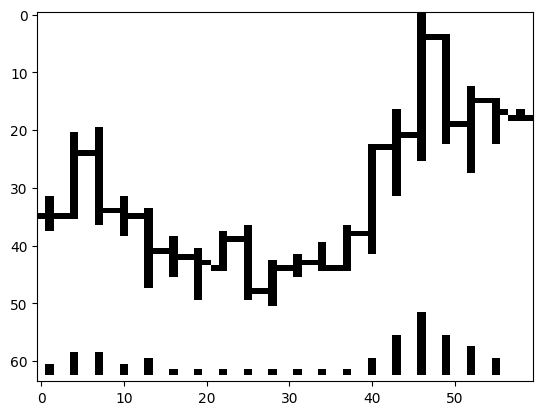

(64, 60)

In [41]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray_r', aspect='auto')
plt.axis('on')
plt.show()
img.shape

# img

In [42]:
img = ohlc_to_image_without_volume(aggregate_process_symbol_data)

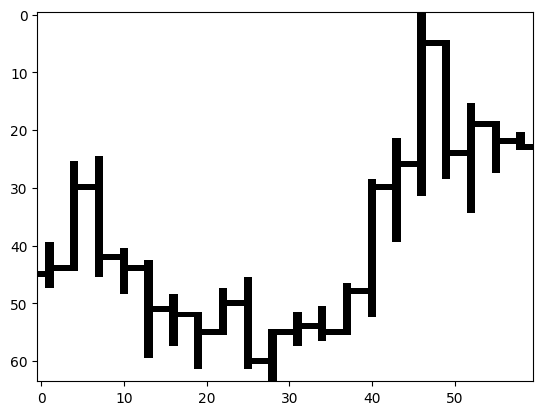

(64, 60)

In [43]:
import matplotlib.pyplot as plt

plt.imshow(img, cmap='gray_r', aspect='auto')
plt.axis('on')
plt.show()
img.shape

# img